# Loan Approval Prediction Project

## Introduction

The ability to predict loan approvals is a critical aspect of risk management in the financial sector. This project focuses on building a machine learning model to determine whether a loan applicant is approved for a loan based on various factors such as credit history, income, loan amount, and other demographic and financial information. By leveraging this predictive model, financial institutions can make more informed decisions, reduce risks, and streamline the loan approval process.

In this project, I aim to explore the dataset provided, conduct thorough data analysis, and develop a robust machine learning pipeline to achieve high prediction accuracy. This competition serves as an excellent opportunity to enhance my skills in data preprocessing, feature engineering, model building, and evaluation.

You can download the dataset and learn more about the competition details from the following link:  
[Playground Series - Season 4, Episode 10](https://www.kaggle.com/competitions/playground-series-s4e10/data)

Let's dive into the data and start building our solution!


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [3]:
train= pd.read_csv("train.csv")
test= pd.read_csv("test.csv")
sub_sam= pd.read_csv("sample_submission.csv")

In [4]:
train.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [5]:
train.describe()

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,58645.000000,58645.000000,5.864500e+04,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000
mean,29322.000000,27.550857,6.404617e+04,4.701015,9217.556518,10.677874,0.159238,5.813556,0.142382
std,16929.497605,6.033216,3.793111e+04,3.959784,5563.807384,3.034697,0.091692,4.029196,0.349445
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000
max,58644.000000,123.000000,1.900000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


In [6]:
train.shape

(58645, 13)

In [7]:
train.isnull().sum()

id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

In [8]:
# categorical and numeric columns
numeric =[]
categorical = []

for i in train.columns:
    if pd.api.types.is_numeric_dtype(train[i]):
        numeric.append(i)
    else:
        categorical.append(i)
        
print(numeric)
print(categorical)

['id', 'person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_status']
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


In [9]:
numeric_test=[]
categorical_test=[]

for i in test.columns:
    if pd.api.types.is_numeric_dtype(test[i]):
        numeric_test.append(i)
    else:
        categorical_test.append(i)

print(numeric_test)
print(categorical_test)

['id', 'person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


<BarContainer object of 58645 artists>

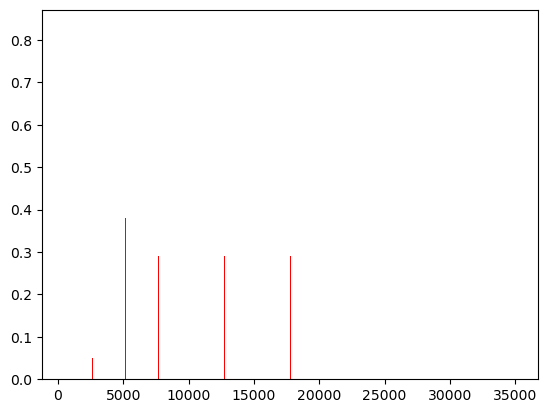

In [10]:
# visualization data
plt.bar(train['loan_amnt'],train['loan_percent_income'],color='red')

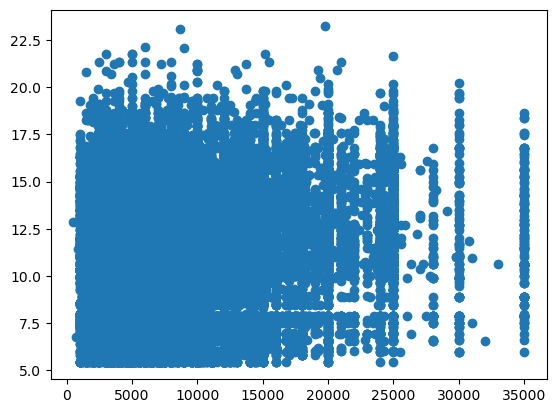

In [11]:
plt.scatter(train['loan_amnt'],train['loan_int_rate'])

<Axes: >

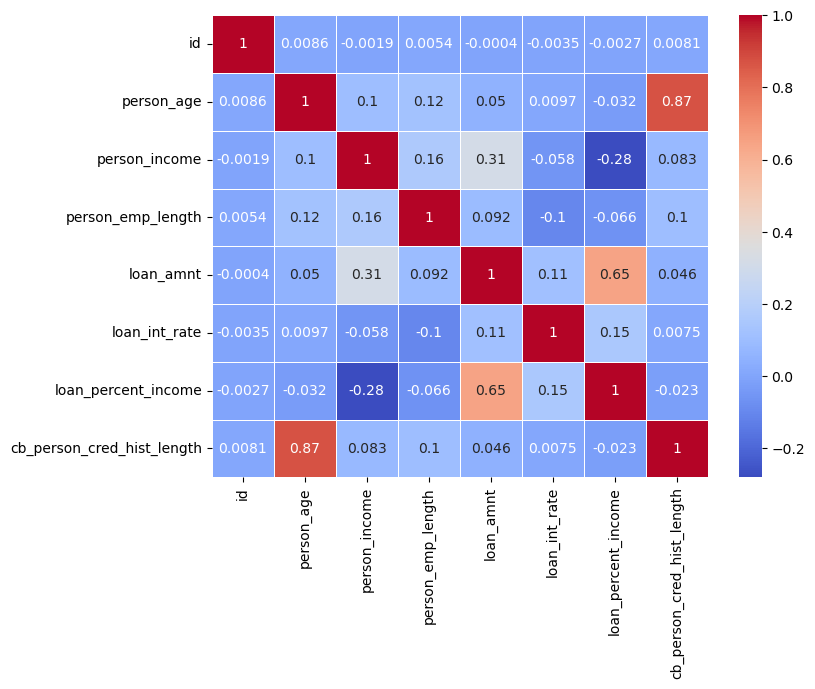

In [12]:
train_nume=train[numeric_test]
corr = train_nume.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)

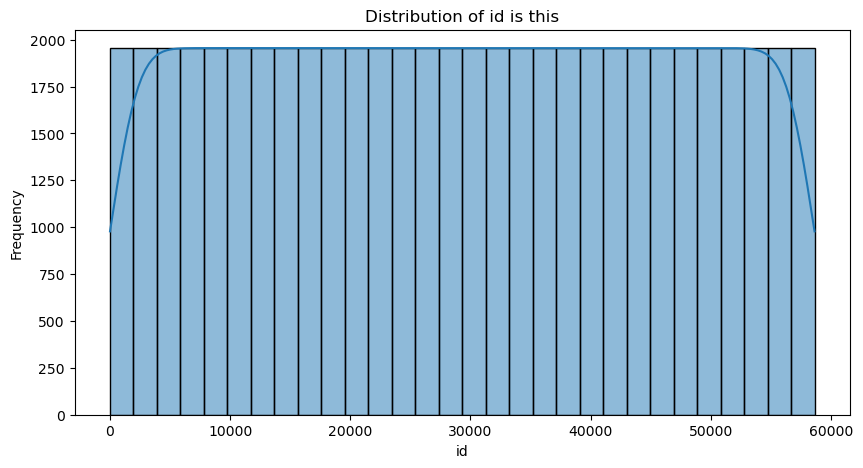

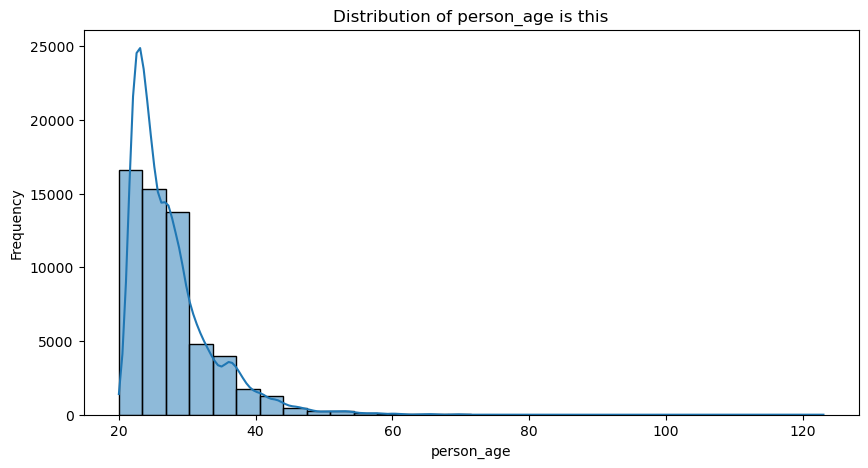

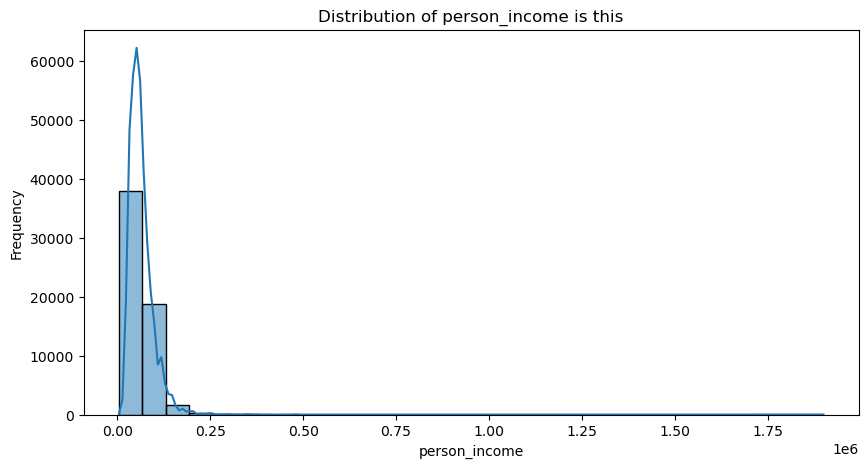

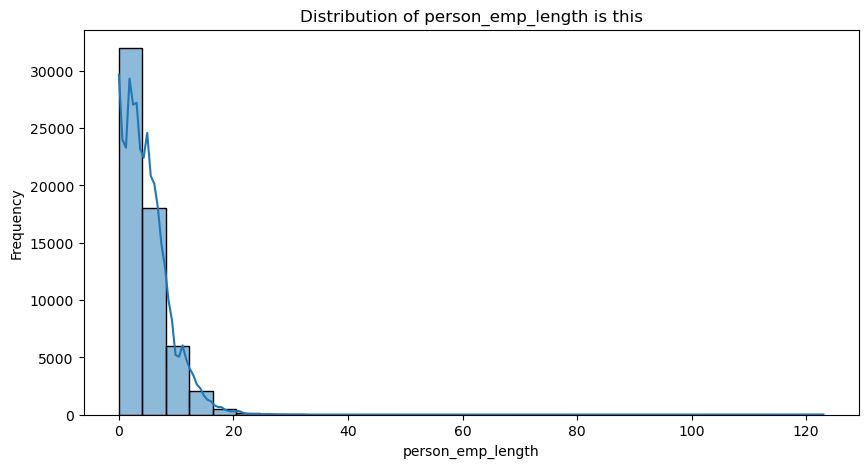

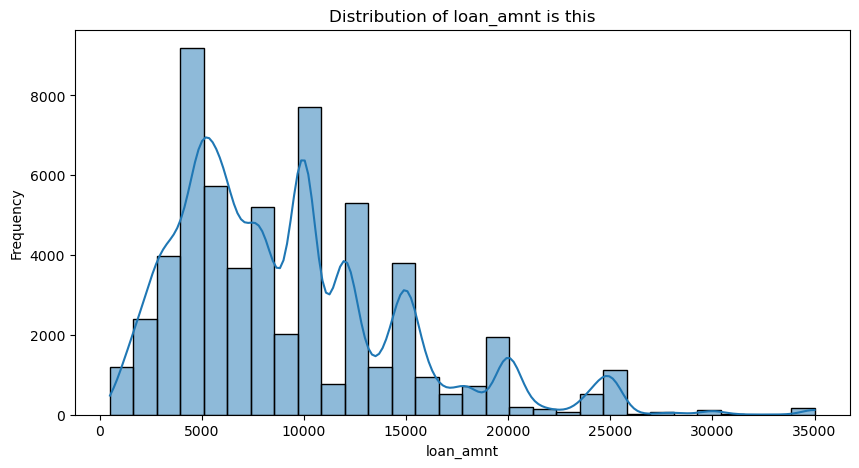

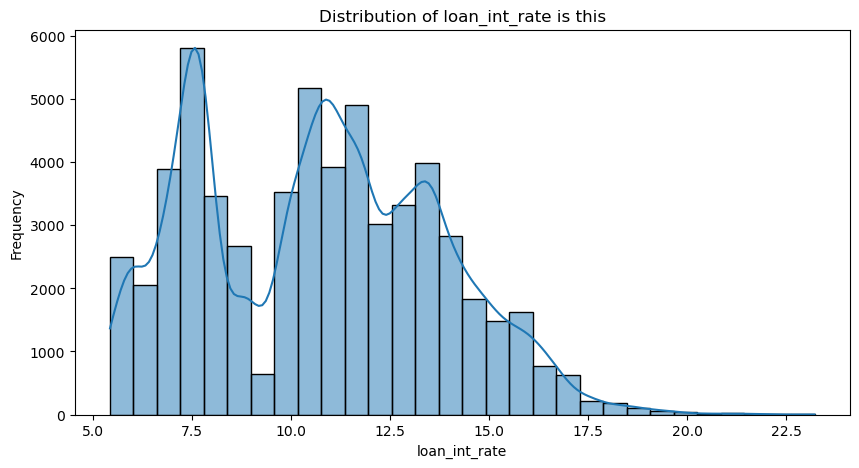

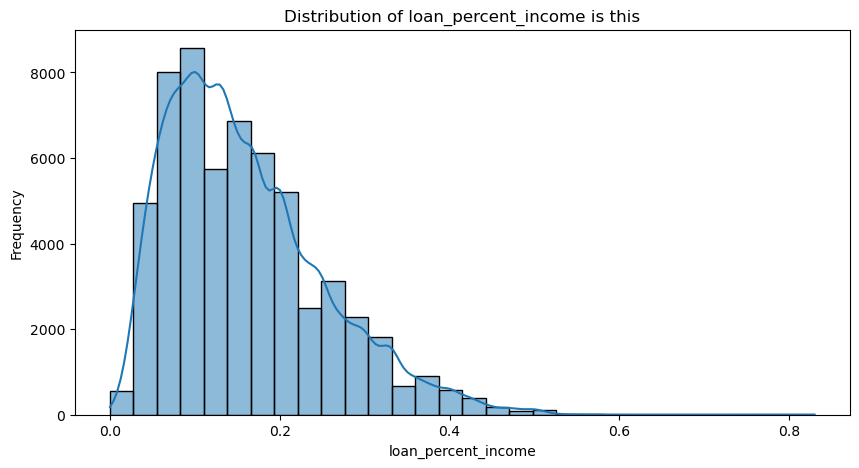

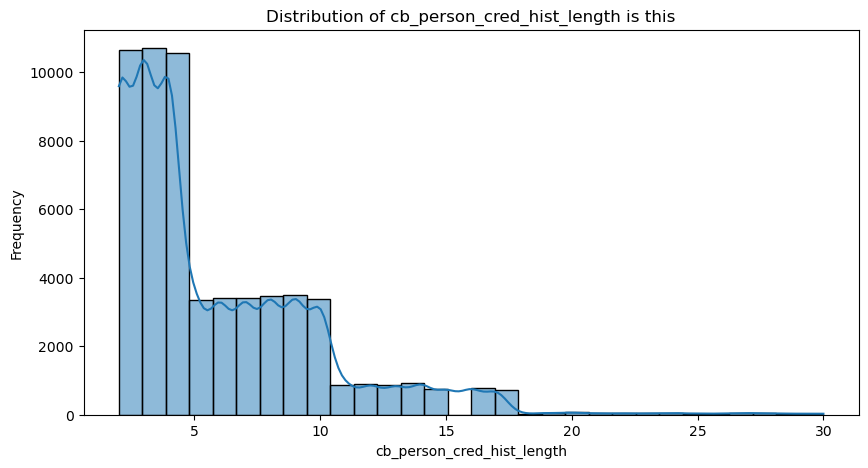

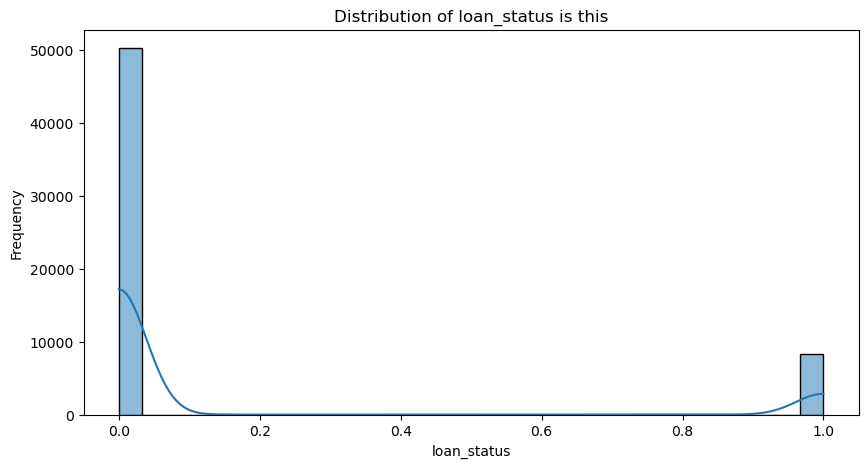

In [13]:
for column in numeric:
    plt.figure(figsize=(10,5))
    sns.histplot(train[column],kde=True,bins=30)
    plt.title(f'Distribution of {column} is this')
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

In [14]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()

In [15]:
for col in categorical:
    train[col]=label_encoder.fit_transform(train[col])

for col in categorical_test:
    test[col]=label_encoder.fit_transform(test[col])

In [16]:
X=train.drop(['id','loan_status'], axis=1)
y=train['loan_status']
test=test.drop(['id'], axis=1)

In [17]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [18]:
model = XGBClassifier(                    
    alpha=0.1,                   
    subsample=0.8,     
    colsample_bytree=0.55,  
    objective='binary:logistic',
    max_depth=14,             
    min_child_weight=7,         
    gamma=1e-6,                
    random_state=42,                 
    n_estimators=100             
    )

In [19]:
XGB = model.fit(X_train , y_train)

In [20]:
y_pred=model.predict(X_test)
y_pred

array([0, 0, 1, ..., 0, 0, 0])

In [21]:
score= accuracy_score(y_test,y_pred)
score

0.9496120726404638

In [23]:
ans=model.predict(test)
ans

array([1, 0, 1, ..., 0, 0, 1])

In [24]:
submission = pd.DataFrame({'id':sub_sam['id'] , 'loan_status': ans})
submission.to_csv('submission.csv' , index = False)
print('Saved')

Saved


## Conclusion

The submission achieved a **Public Score of 0.86953** and a **Private Score of 0.85190**, demonstrating strong performance in predicting loan approvals. This project provided valuable experience in data preprocessing, feature engineering, and model building. Future improvements could focus on advanced feature selection and ensemble techniques to further enhance accuracy and generalization.


In [ ]:
ans=rf.predict(test)
ans